In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

# Plot stil
plt.style.use('default')
sns.set_palette("husl")

# Yollar
PROJECT = Path('/content/drive/MyDrive/DR_Project')
APTOS = PROJECT / 'datasets' / 'APTOS'
IDRID = PROJECT / 'datasets' / 'IDRiD'
IDRID_SEG = IDRID / 'A. Segmentation'
IDRID_GRD = IDRID / 'B. Disease Grading'

# Rapor figure klasoru
FIGS = PROJECT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# DR sinif isimleri (raporda kullanilacak)
DR_NAMES = {
    0: 'No DR',
    1: 'Hafif (Mild)',
    2: 'Orta (Moderate)',
    3: 'Siddetli (Severe)',
    4: 'Proliferatif (PDR)'
}

print("Setup tamam.")
print("Figures kaydedilecek:", FIGS)

Mounted at /content/drive
Setup tamam.
Figures kaydedilecek: /content/drive/MyDrive/DR_Project/reports/figures


In [6]:
import os
from pathlib import Path

PROJECT = Path('/content/drive/MyDrive/DR_Project')
IDRID_GRD = PROJECT / 'datasets' / 'IDRiD' / 'B. Disease Grading'

print("B. Disease Grading icerigi:")
for item in os.listdir(IDRID_GRD):
    print(" -", repr(item))

gt = IDRID_GRD / '2. Groundtruths'
if gt.exists():
    print("\n2. Groundtruths icerigi:")
    for item in os.listdir(gt):
        print(" -", repr(item))
else:
    print("\n2. Groundtruths bulunamadi! Asagidaki olasi yollari ariyorum:")
    for item in os.listdir(IDRID_GRD):
        if 'round' in item.lower() or 'truth' in item.lower():
            print(" Aday:", repr(item))

B. Disease Grading icerigi:
 - 'B. Disease Grading'
 - 'LICENSE.txt'
 - 'CC-BY-4.0.txt'

2. Groundtruths bulunamadi! Asagidaki olasi yollari ariyorum:


In [7]:
import os, shutil
from pathlib import Path

PROJECT = Path('/content/drive/MyDrive/DR_Project')
IDRID = PROJECT / 'datasets' / 'IDRiD'

# Her ic ice klasoru cozelim
for top in ['A. Segmentation', 'B. Disease Grading']:
    outer = IDRID / top
    inner = outer / top

    if inner.exists() and inner.is_dir():
        print(f"Ic ice klasor bulundu: {outer}")
        # Ic klasordeki her seyi disariya tasi
        for child in os.listdir(inner):
            src = inner / child
            dst = outer / child
            if dst.exists():
                # Cakisma varsa eski olani sil
                if dst.is_dir():
                    shutil.rmtree(dst)
                else:
                    dst.unlink()
            shutil.move(str(src), str(dst))
        # Bos klasoru sil
        os.rmdir(inner)
        print(f"  Cozuldu: {top}")
    else:
        print(f"OK: {top} (zaten duz yapida)")

# Sonuc
print("\n=== Final IDRiD yapisi ===")
for top in sorted(os.listdir(IDRID)):
    print(f"{top}/")
    sub = IDRID / top
    if sub.is_dir():
        for s in sorted(os.listdir(sub)):
            print(f"   {s}")

OK: A. Segmentation (zaten duz yapida)
OK: B. Disease Grading (zaten duz yapida)

=== Final IDRiD yapisi ===
A. Segmentation/
   1. Original Images
   2. All Segmentation Groundtruths
   CC-BY-4.0.txt
   LICENSE.txt
B. Disease Grading/
   1. Original Images
   2. Groundtruths
   CC-BY-4.0.txt
   LICENSE.txt


In [8]:
import os
from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/DR_Project')
gt_dir = PROJECT / 'datasets' / 'IDRiD' / 'B. Disease Grading' / '2. Groundtruths'
print("Var mi:", gt_dir.exists())
print("Icerik:")
for f in os.listdir(gt_dir):
    print(" -", repr(f))

Var mi: True
Icerik:
 - 'a. IDRiD_Disease Grading_Training Labels.csv'
 - 'b. IDRiD_Disease Grading_Testing Labels.csv'


Sinif dagilim tablosu:
                    APTOS  IDRiD-B (train)  Toplam
No DR                1805              134    1939
Hafif (Mild)          370               20     390
Orta (Moderate)       999              136    1135
Siddetli (Severe)     193               74     267
Proliferatif (PDR)    295               49     344


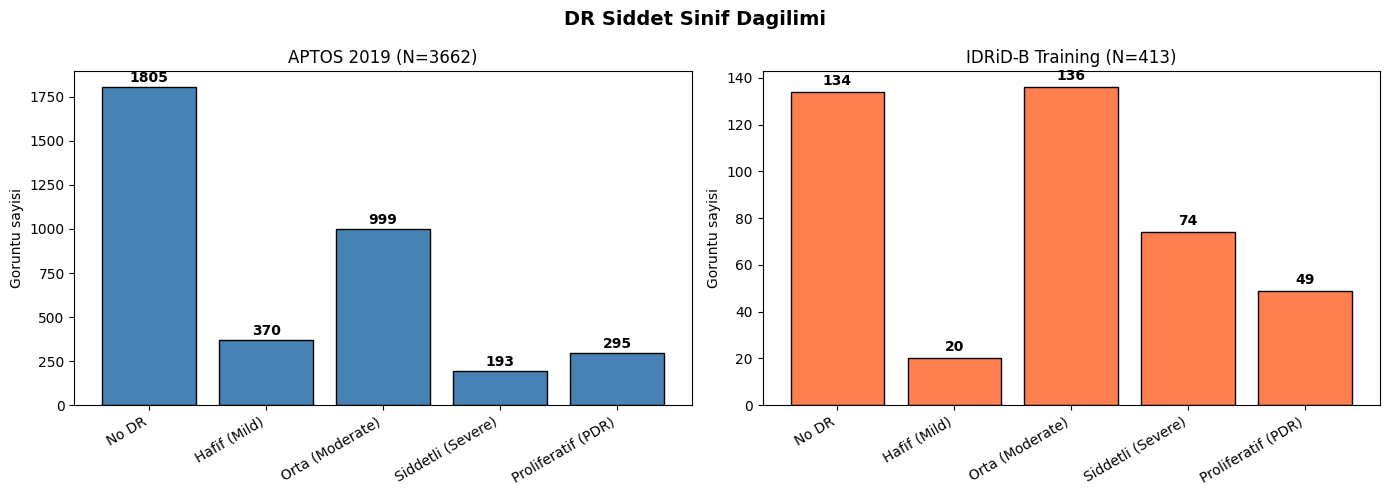


Kaydedildi: /content/drive/MyDrive/DR_Project/reports/figures/fig01_class_distribution.png


In [9]:
# APTOS
aptos_df = pd.read_csv(APTOS / 'train.csv')
aptos_counts = aptos_df['diagnosis'].value_counts().sort_index()

# IDRiD-B train
idrid_csv = IDRID_GRD / '2. Groundtruths' / 'a. IDRiD_Disease Grading_Training Labels.csv'
idrid_df = pd.read_csv(idrid_csv)
idrid_df = idrid_df[['Image name', 'Retinopathy grade']].dropna()
idrid_df['Retinopathy grade'] = idrid_df['Retinopathy grade'].astype(int)
idrid_counts = idrid_df['Retinopathy grade'].value_counts().sort_index()

# Combined
combined = pd.DataFrame({
    'APTOS': aptos_counts,
    'IDRiD-B (train)': idrid_counts
}).fillna(0).astype(int)
combined['Toplam'] = combined.sum(axis=1)
combined.index = [DR_NAMES[i] for i in combined.index]

print("Sinif dagilim tablosu:")
print(combined)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: APTOS
axes[0].bar(range(5), aptos_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([DR_NAMES[i] for i in range(5)], rotation=30, ha='right')
axes[0].set_ylabel('Goruntu sayisi')
axes[0].set_title(f'APTOS 2019 (N={aptos_counts.sum()})')
for i, v in enumerate(aptos_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Sag: IDRiD-B
axes[1].bar(range(5), idrid_counts.values, color='coral', edgecolor='black')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([DR_NAMES[i] for i in range(5)], rotation=30, ha='right')
axes[1].set_ylabel('Goruntu sayisi')
axes[1].set_title(f'IDRiD-B Training (N={idrid_counts.sum()})')
for i, v in enumerate(idrid_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('DR Siddet Sinif Dagilimi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'fig01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKaydedildi: {FIGS / 'fig01_class_distribution.png'}")

APTOS goruntu boyut istatistikleri (100 ornek):
  Genislik: min=640, max=4288, ort=1986
  Yukseklik: min=480, max=2848, ort=1511

IDRiD-Segmentation goruntu boyutu: (4288, 2848) (sabit)
IDRiD-Grading goruntu boyutu: (4288, 2848) (sabit)


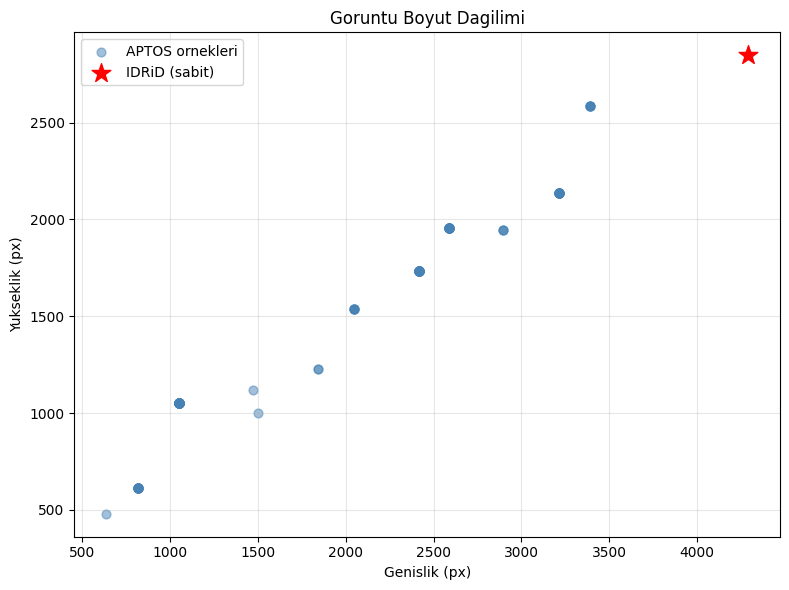

In [10]:
import random
random.seed(42)

# APTOS'tan 100 ornek (3662 tane var, hepsini acmak gereksiz)
aptos_imgs = list((APTOS / 'train_images').glob('*.png'))
sample = random.sample(aptos_imgs, 100)

sizes = []
for p in sample:
    with Image.open(p) as img:
        sizes.append(img.size)

sizes = np.array(sizes)
print("APTOS goruntu boyut istatistikleri (100 ornek):")
print(f"  Genislik: min={sizes[:,0].min()}, max={sizes[:,0].max()}, ort={sizes[:,0].mean():.0f}")
print(f"  Yukseklik: min={sizes[:,1].min()}, max={sizes[:,1].max()}, ort={sizes[:,1].mean():.0f}")

# IDRiD boyutu (zaten gordukn 4288x2848)
idrid_seg_train = list((IDRID_SEG / '1. Original Images' / 'a. Training Set').glob('*.jpg'))
with Image.open(idrid_seg_train[0]) as img:
    print(f"\nIDRiD-Segmentation goruntu boyutu: {img.size} (sabit)")

idrid_grd_train = list((IDRID_GRD / '1. Original Images' / 'a. Training Set').glob('*.jpg'))
with Image.open(idrid_grd_train[0]) as img:
    print(f"IDRiD-Grading goruntu boyutu: {img.size} (sabit)")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sizes[:,0], sizes[:,1], alpha=0.5, s=40, color='steelblue', label='APTOS ornekleri')
ax.scatter([4288], [2848], color='red', s=200, marker='*', label='IDRiD (sabit)', zorder=5)
ax.set_xlabel('Genislik (px)')
ax.set_ylabel('Yukseklik (px)')
ax.set_title('Goruntu Boyut Dagilimi')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'fig02_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

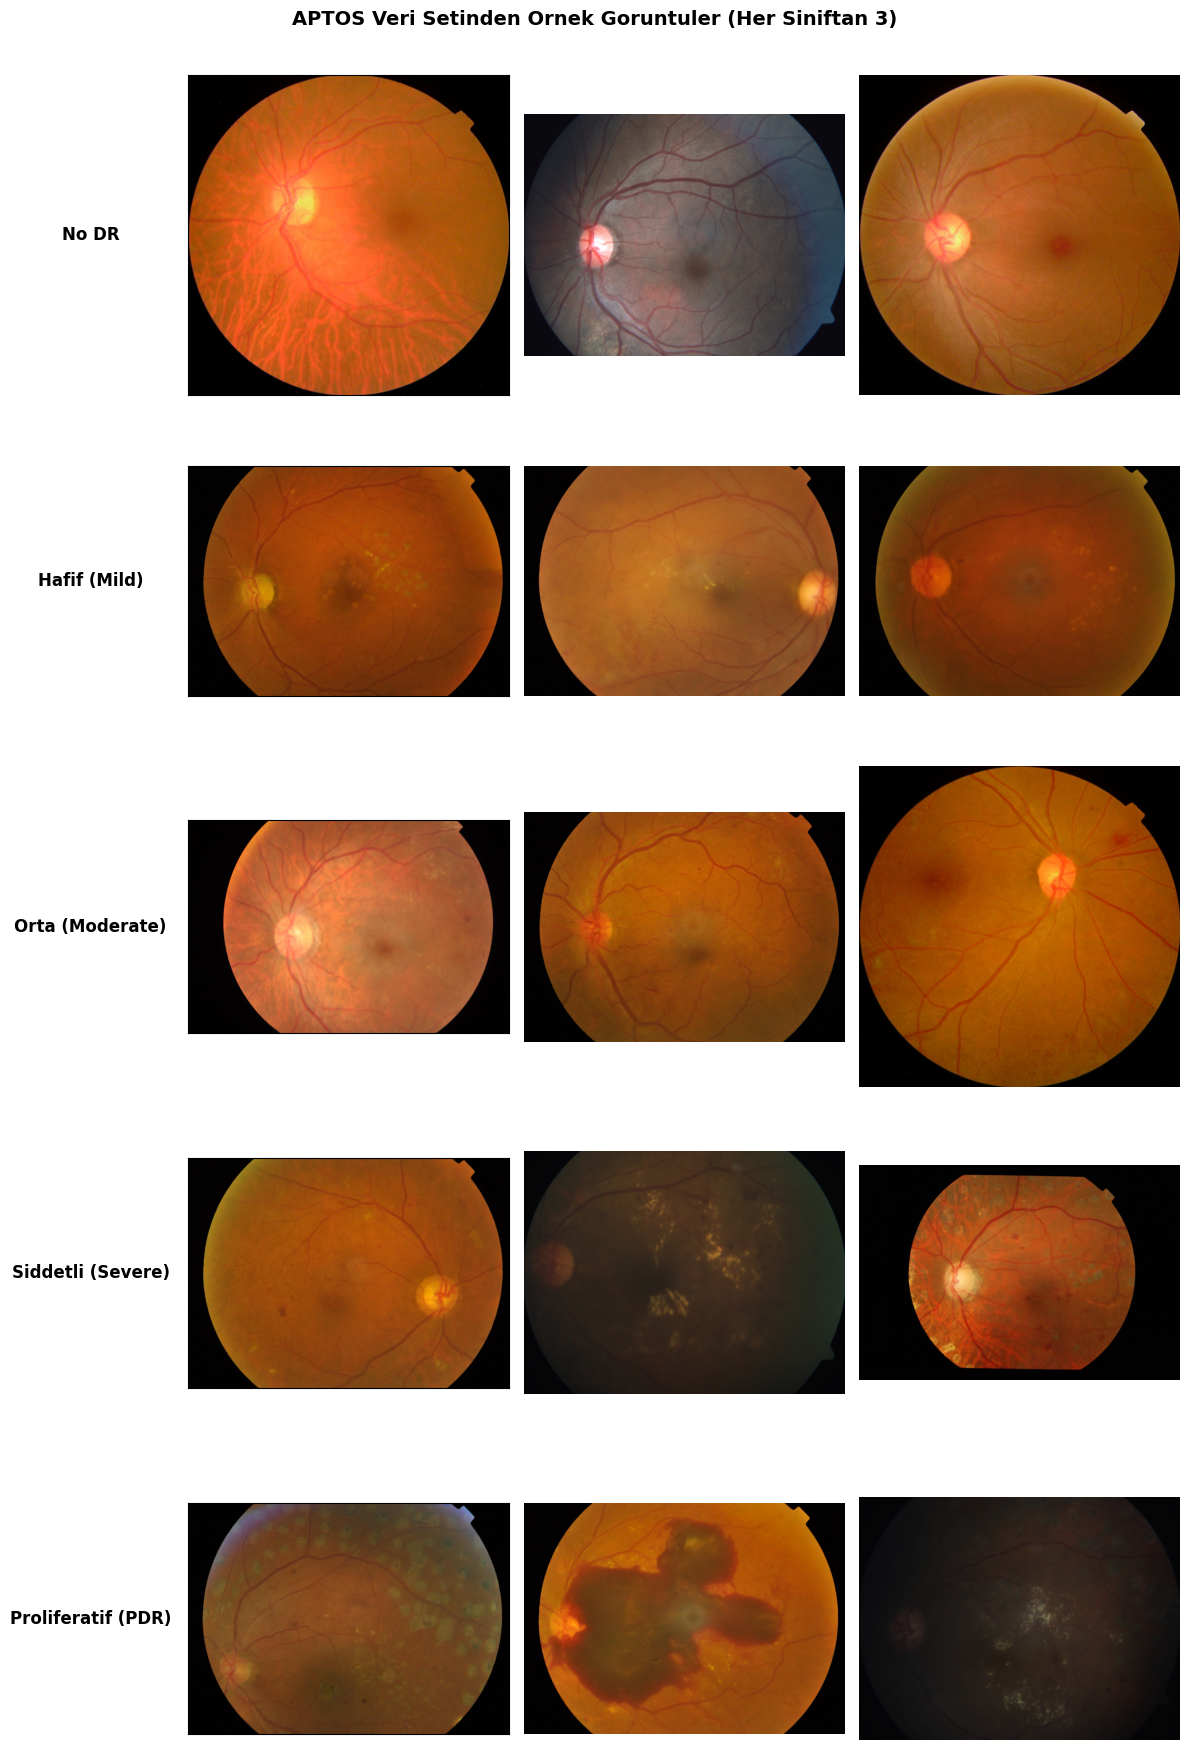

In [11]:
fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for cls in range(5):
    # Bu siniftan 3 rastgele goruntu
    cls_ids = aptos_df[aptos_df['diagnosis'] == cls]['id_code'].sample(3, random_state=42).values
    for j, id_code in enumerate(cls_ids):
        img_path = APTOS / 'train_images' / f'{id_code}.png'
        img = Image.open(img_path)
        axes[cls, j].imshow(img)
        axes[cls, j].axis('off')
        if j == 0:
            axes[cls, j].set_ylabel(DR_NAMES[cls], fontsize=12, fontweight='bold', rotation=0,
                                    labelpad=70, va='center')
            axes[cls, j].axis('on')
            axes[cls, j].set_xticks([])
            axes[cls, j].set_yticks([])

plt.suptitle('APTOS Veri Setinden Ornek Goruntuler (Her Siniftan 3)', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(FIGS / 'fig03_aptos_samples.png', dpi=120, bbox_inches='tight')
plt.show()

Secilen goruntu: IDRiD_11


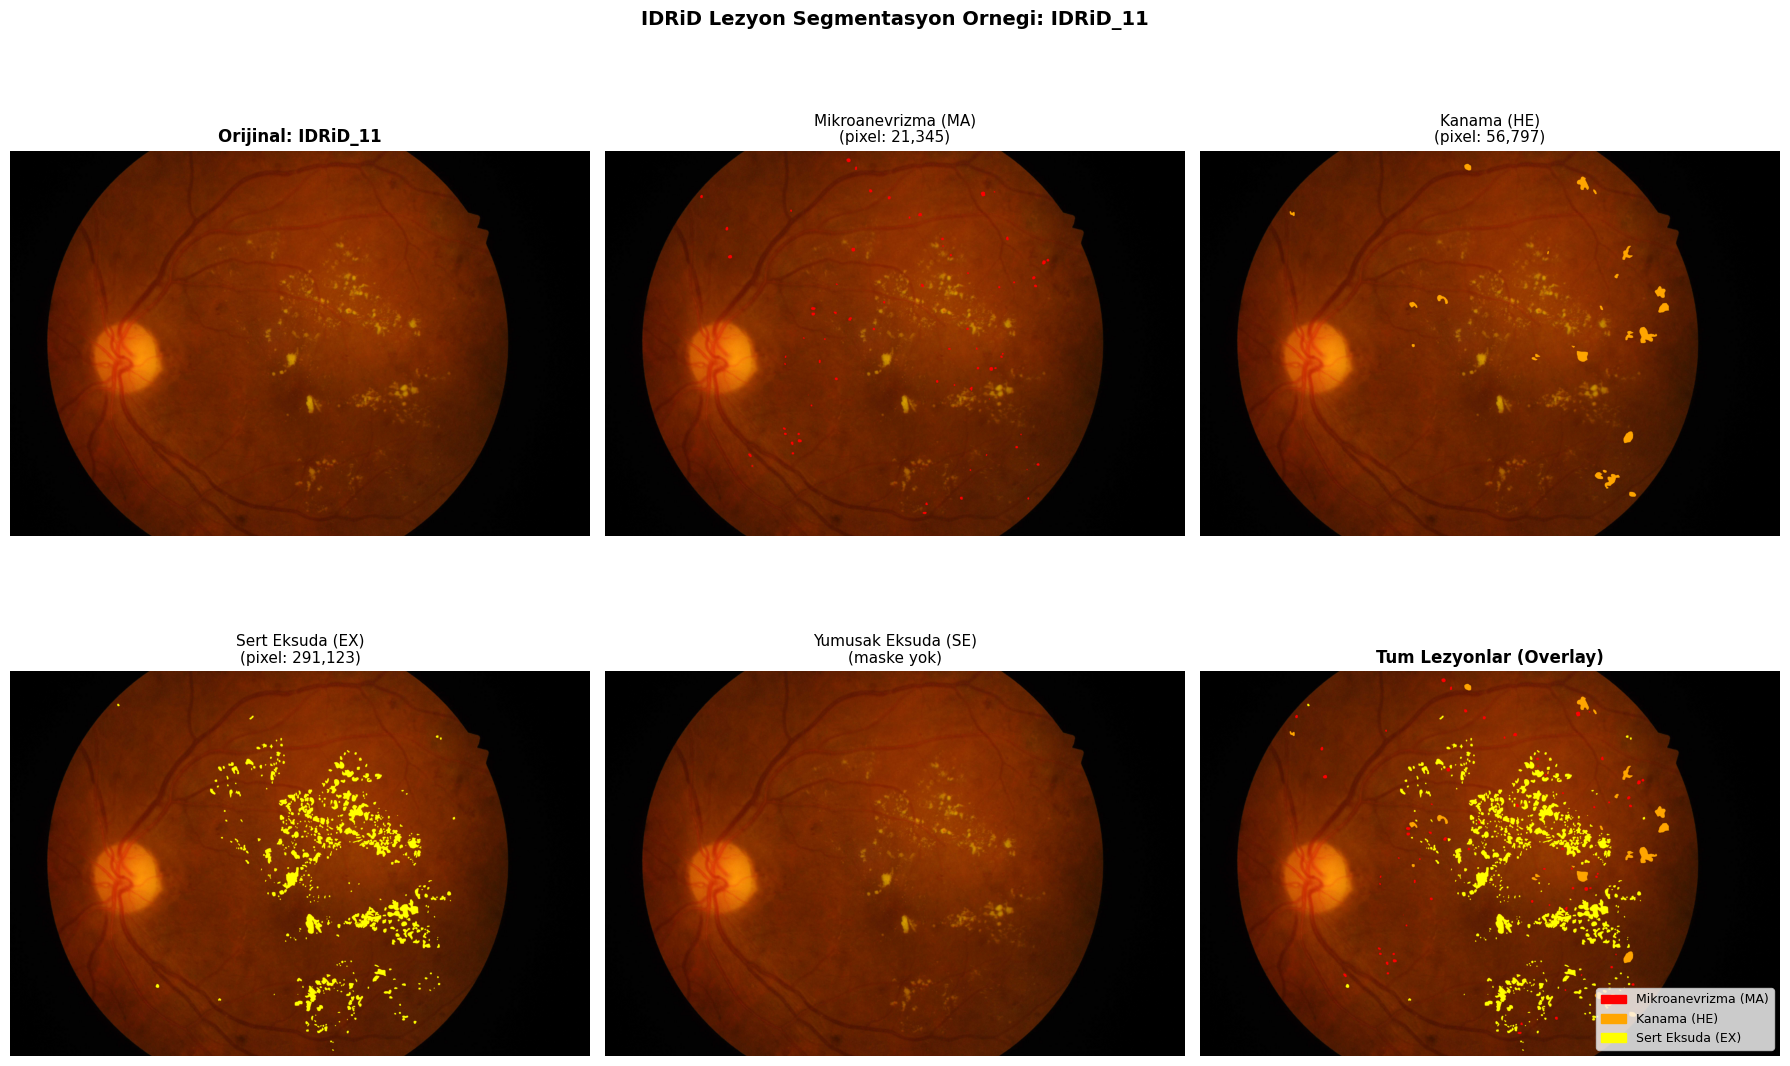

In [12]:
import cv2

# IDRiD Training set'ten bir goruntu sec (lezyonlu bir tane)
img_files = sorted((IDRID_SEG / '1. Original Images' / 'a. Training Set').glob('*.jpg'))
sample_idx = 10  # Genelde lezyon dolu
img_path = img_files[sample_idx]
img_name = img_path.stem  # IDRiD_11 gibi

print(f"Secilen goruntu: {img_name}")

# Goruntuyu yukle
img = np.array(Image.open(img_path))

# 4 lezyon maskesini yukle
mask_root = IDRID_SEG / '2. All Segmentation Groundtruths' / 'a. Training Set'
lesion_dirs = {
    'Mikroanevrizma (MA)': '1. Microaneurysms',
    'Kanama (HE)': '2. Haemorrhages',
    'Sert Eksuda (EX)': '3. Hard Exudates',
    'Yumusak Eksuda (SE)': '4. Soft Exudates',
}
lesion_colors = {
    'Mikroanevrizma (MA)': (255, 0, 0),     # kirmizi
    'Kanama (HE)': (255, 165, 0),            # turuncu
    'Sert Eksuda (EX)': (255, 255, 0),       # sari
    'Yumusak Eksuda (SE)': (0, 255, 255),    # cyan
}

# Her lezyon maskesini ayri panelde goster + overlay
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Panel 0: Orijinal
axes[0].imshow(img)
axes[0].set_title(f'Orijinal: {img_name}', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel 1-4: Her lezyon
overlay = img.copy()
legend_patches = []
import matplotlib.patches as mpatches

for i, (name, subdir) in enumerate(lesion_dirs.items(), start=1):
    mask_path = mask_root / subdir / f'{img_name}_{subdir.split(". ")[1][:2].upper()}.tif'
    # IDRiD naming: IDRiD_11_MA.tif, IDRiD_11_HE.tif, IDRiD_11_EX.tif, IDRiD_11_SE.tif
    suffix_map = {'1. Microaneurysms': 'MA', '2. Haemorrhages': 'HE',
                  '3. Hard Exudates': 'EX', '4. Soft Exudates': 'SE'}
    mask_path = mask_root / subdir / f'{img_name}_{suffix_map[subdir]}.tif'

    if mask_path.exists():
        mask = np.array(Image.open(mask_path))
        if mask.ndim == 3:
            mask = mask[:,:,0]
        binary = (mask > 0).astype(np.uint8)

        # Tek lezyon panel
        panel = img.copy()
        color = lesion_colors[name]
        panel[binary > 0] = color
        axes[i].imshow(panel)
        axes[i].set_title(f'{name}\n(pixel: {binary.sum():,})', fontsize=11)
        axes[i].axis('off')

        # Overlay'e ekle
        overlay[binary > 0] = color
        legend_patches.append(mpatches.Patch(color=np.array(color)/255, label=name))
    else:
        axes[i].imshow(img)
        axes[i].set_title(f'{name}\n(maske yok)', fontsize=11)
        axes[i].axis('off')

# Panel 5: Tum lezyonlar overlay
axes[5].imshow(overlay)
axes[5].set_title('Tum Lezyonlar (Overlay)', fontsize=12, fontweight='bold')
axes[5].axis('off')
axes[5].legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.suptitle(f'IDRiD Lezyon Segmentasyon Ornegi: {img_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'fig04_idrid_lesion_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
summary = f"""
===================================================
VERI SETI OZET ISTATISTIKLERI (raporda kullan)
===================================================

A) APTOS 2019 Blindness Detection
   - Toplam goruntu: {len(aptos_df):,}
   - Kaynak: Asia Pacific Tele-Ophthalmology Society
   - Cozunurluk: degisken (yuzlerce-binlerce px)
   - Sinif dagilimi:
       0 (No DR):         {aptos_counts.get(0,0):,} (%{aptos_counts.get(0,0)/len(aptos_df)*100:.1f})
       1 (Mild):          {aptos_counts.get(1,0):,} (%{aptos_counts.get(1,0)/len(aptos_df)*100:.1f})
       2 (Moderate):      {aptos_counts.get(2,0):,} (%{aptos_counts.get(2,0)/len(aptos_df)*100:.1f})
       3 (Severe):        {aptos_counts.get(3,0):,} (%{aptos_counts.get(3,0)/len(aptos_df)*100:.1f})
       4 (Proliferative): {aptos_counts.get(4,0):,} (%{aptos_counts.get(4,0)/len(aptos_df)*100:.1f})

B) IDRiD Disease Grading
   - Train: {len(idrid_df):,} | Test: 103
   - Kaynak: Indian Institute of Technology
   - Cozunurluk: 4288 x 2848 (sabit)
   - Train sinif dagilimi:
       0: {idrid_counts.get(0,0)} | 1: {idrid_counts.get(1,0)} | 2: {idrid_counts.get(2,0)} | 3: {idrid_counts.get(3,0)} | 4: {idrid_counts.get(4,0)}

C) IDRiD Segmentation
   - Train: 54 | Test: 27 (Toplam 81)
   - Cozunurluk: 4288 x 2848
   - Lezyon tipi: 4 (MA, HE, EX, SE) + Optic Disc

===================================================
TOPLAM:
   Siniflandirma: {len(aptos_df) + len(idrid_df):,} train + 103 external test
   Segmentasyon:  81 (4 lezyon pixel-level maskeli)
===================================================
"""
print(summary)

# Drive'a metin olarak kaydet
with open(FIGS.parent / 'eda_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print(f"\nOzet kaydedildi: {FIGS.parent / 'eda_summary.txt'}")


VERI SETI OZET ISTATISTIKLERI (raporda kullan)

A) APTOS 2019 Blindness Detection
   - Toplam goruntu: 3,662
   - Kaynak: Asia Pacific Tele-Ophthalmology Society
   - Cozunurluk: degisken (yuzlerce-binlerce px)
   - Sinif dagilimi:
       0 (No DR):         1,805 (%49.3)
       1 (Mild):          370 (%10.1)
       2 (Moderate):      999 (%27.3)
       3 (Severe):        193 (%5.3)
       4 (Proliferative): 295 (%8.1)

B) IDRiD Disease Grading
   - Train: 413 | Test: 103
   - Kaynak: Indian Institute of Technology
   - Cozunurluk: 4288 x 2848 (sabit)
   - Train sinif dagilimi:
       0: 134 | 1: 20 | 2: 136 | 3: 74 | 4: 49

C) IDRiD Segmentation
   - Train: 54 | Test: 27 (Toplam 81)
   - Cozunurluk: 4288 x 2848
   - Lezyon tipi: 4 (MA, HE, EX, SE) + Optic Disc

TOPLAM:
   Siniflandirma: 4,075 train + 103 external test
   Segmentasyon:  81 (4 lezyon pixel-level maskeli)


Ozet kaydedildi: /content/drive/MyDrive/DR_Project/reports/eda_summary.txt
